# Hyperdimensional Transformer (HDT) para Clasificación Molecular
## Fusión con Atención: Integrando BiHDTrans al pipeline BBBP

Este notebook implementa un **Hyperdimensional Transformer (HDT)** inspirado en BiHDTrans (Zhang et al., 2025) y lo aplica al mismo problema de la Semana 4: clasificación de permeabilidad barrera sangre-cerebro (BBBP).

**Pregunta de investigación:** ¿La mejora sobre el clasificador por prototipos de la Semana 4 se debe al mecanismo de atención, o simplemente a tener una representación más rica?

**Referencia:** Zhang, J., Liu, Y., Shen, Q., Wang, C. — *BiHDTrans: Binary Hyperdimensional Transformer for Efficient Multivariate Time Series Classification* — arXiv:2509.24425 (2025)

**Dataset:** BBBP | **Dimensión:** D = 10.000 | **Cabezas de atención:** 4


## 0. Dependencias

In [1]:
import importlib, subprocess, sys
for pkg in ["rdkit"]:
    if importlib.util.find_spec(pkg) is None:
        subprocess.check_call([sys.executable, "-m", "pip", "install", pkg, "-q"])

import warnings
warnings.filterwarnings("ignore")
print("✓ Dependencias listas")


✓ Dependencias listas


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import urllib.request, io

from rdkit import Chem
from rdkit.Chem import AllChem, Descriptors
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, accuracy_score, f1_score

# ── Hiperparámetros globales ────────────────────────────────────────────────
SEED    = 42
D       = 10_000   # dimensión de los hipervectores
N_HEADS = 4        # cabezas de atención
D_PROJ  = 256      # dimensión de proyección por cabeza (D_PROJ * N_HEADS = D_OUT)
D_OUT   = N_HEADS * D_PROJ  # 1024 — salida del bloque de atención
N_LEVELS   = 100
ECFP_NBITS = 2048

np.random.seed(SEED)
print(f"D={D:,} | N_HEADS={N_HEADS} | D_PROJ={D_PROJ} | D_OUT={D_OUT}")


D=10,000 | N_HEADS=4 | D_PROJ=256 | D_OUT=1024


## 1. Preparación de Datos

Usamos exactamente el mismo pipeline de la Semana 4: dataset BBBP, descriptores MW / LogP / MR normalizados, y ECFP4 para la representación estructural.


In [3]:
# ── Descarga y sanitización ──────────────────────────────────────────────────
URL = ("https://raw.githubusercontent.com/GLambard/Molecules_Dataset_Collection"
       "/master/originals/BBBP.csv")
with urllib.request.urlopen(URL) as r:
    df = pd.read_csv(io.StringIO(r.read().decode()))

df["mol"] = df["smiles"].apply(Chem.MolFromSmiles)
df = df[df["mol"].notna()].reset_index(drop=True)
print(f"Moléculas válidas: {len(df)}")
print(df["p_np"].value_counts().to_string())


[10:37:45] Explicit valence for atom # 1 N, 4, is greater than permitted
[10:37:45] WARNING: not removing hydrogen atom without neighbors
[10:37:45] Explicit valence for atom # 6 N, 4, is greater than permitted
[10:37:45] WARNING: not removing hydrogen atom without neighbors
[10:37:45] WARNING: not removing hydrogen atom without neighbors
[10:37:45] WARNING: not removing hydrogen atom without neighbors
[10:37:45] WARNING: not removing hydrogen atom without neighbors
[10:37:45] WARNING: not removing hydrogen atom without neighbors
[10:37:45] WARNING: not removing hydrogen atom without neighbors
[10:37:46] Explicit valence for atom # 6 N, 4, is greater than permitted
[10:37:46] WARNING: not removing hydrogen atom without neighbors
[10:37:46] WARNING: not removing hydrogen atom without neighbors
[10:37:46] WARNING: not removing hydrogen atom without neighbors
[10:37:46] WARNING: not removing hydrogen atom without neighbors
[10:37:46] Explicit valence for atom # 11 N, 4, is greater than pe

Moléculas válidas: 2039
p_np
1    1560
0     479


[10:37:47] WARNING: not removing hydrogen atom without neighbors
[10:37:47] WARNING: not removing hydrogen atom without neighbors


In [4]:
# ── Descriptores fisicoquímicos (Semana 4, Tarea 1) ──────────────────────────
df["MW"]   = df["mol"].apply(Descriptors.MolWt)
df["LogP"] = df["mol"].apply(Descriptors.MolLogP)
df["MR"]   = df["mol"].apply(Descriptors.MolMR)

scaler = MinMaxScaler()
df[["MW_n","LogP_n","MR_n"]] = scaler.fit_transform(df[["MW","LogP","MR"]])
print("✓ Descriptores normalizados")
print(df[["MW","LogP","MR"]].describe().round(2))


✓ Descriptores normalizados
            MW     LogP       MR
count  2039.00  2039.00  2039.00
mean    344.54     2.32    92.03
std     150.65     2.09    38.06
min      28.05   -11.74     8.86
25%     256.81     1.25    70.35
50%     324.41     2.47    90.63
75%     410.77     3.75   108.32
max    1879.68    10.81   453.17


## 2. Codificación Base (Semana 4)

Reproducimos `h_struct` (ECFP → proyección bipolar) y `h_prop` (Level-HVs de MW, LogP, MR), idénticos a la Semana 4, para usarlos como la secuencia de entrada al bloque de atención.


In [5]:
# ── Proyección ECFP → h_struct ──────────────────────────────────────────────
rng_proj = np.random.default_rng(SEED)
proj_ecfp = rng_proj.choice([-1, 1], size=(ECFP_NBITS, D)).astype(np.float32)

def mol_to_hstruct(mol: Chem.Mol) -> np.ndarray:
    fp = np.array(AllChem.GetMorganFingerprintAsBitVect(mol, radius=2, nBits=ECFP_NBITS),
                  dtype=np.float32)
    hv = np.sign(fp @ proj_ecfp)
    hv[hv == 0] = 1
    assert hv.shape == (D,)
    return hv

# ── Level-HVs → h_prop ───────────────────────────────────────────────────────
rng_lv = np.random.default_rng(SEED)
base = rng_lv.choice([-1, 1], size=D).astype(np.int8)
level_hvs_list = [base.copy()]
flip_per_step = D // N_LEVELS
for _ in range(N_LEVELS - 1):
    v = level_hvs_list[-1].copy()
    idx = rng_lv.choice(D, size=flip_per_step, replace=False)
    v[idx] *= -1
    level_hvs_list.append(v)
level_hvs = np.array(level_hvs_list, dtype=np.float32)  # (N_LEVELS, D)

def encode_scalar(val_norm: float) -> np.ndarray:
    idx = min(int(val_norm * N_LEVELS), N_LEVELS - 1)
    return level_hvs[idx]

def mol_to_hprop(row) -> np.ndarray:
    hvs = np.stack([encode_scalar(row["MW_n"]),
                    encode_scalar(row["LogP_n"]),
                    encode_scalar(row["MR_n"])])   # (3, D)
    out = np.sign(hvs.sum(axis=0))
    out[out == 0] = 1
    return out

print("Codificando h_struct y h_prop para todas las moléculas...")
h_struct_all = np.array([mol_to_hstruct(m) for m in df["mol"]], dtype=np.float32)
h_prop_all   = np.array([mol_to_hprop(row) for _, row in df.iterrows()], dtype=np.float32)

assert h_struct_all.shape == (len(df), D)
assert h_prop_all.shape   == (len(df), D)
print(f"✓ h_struct: {h_struct_all.shape}")
print(f"✓ h_prop:   {h_prop_all.shape}")


Codificando h_struct y h_prop para todas las moléculas...


[10:38:40] DEPRECATION WARNING: please use MorganGenerator
[10:38:40] DEPRECATION WARNING: please use MorganGenerator
[10:38:40] DEPRECATION WARNING: please use MorganGenerator
[10:38:40] DEPRECATION WARNING: please use MorganGenerator
[10:38:40] DEPRECATION WARNING: please use MorganGenerator
[10:38:40] DEPRECATION WARNING: please use MorganGenerator
[10:38:40] DEPRECATION WARNING: please use MorganGenerator
[10:38:40] DEPRECATION WARNING: please use MorganGenerator
[10:38:40] DEPRECATION WARNING: please use MorganGenerator
[10:38:40] DEPRECATION WARNING: please use MorganGenerator
[10:38:40] DEPRECATION WARNING: please use MorganGenerator
[10:38:40] DEPRECATION WARNING: please use MorganGenerator
[10:38:40] DEPRECATION WARNING: please use MorganGenerator
[10:38:40] DEPRECATION WARNING: please use MorganGenerator
[10:38:40] DEPRECATION WARNING: please use MorganGenerator
[10:38:40] DEPRECATION WARNING: please use MorganGenerator
[10:38:40] DEPRECATION WARNING: please use MorganGenerat

✓ h_struct: (2039, 10000)
✓ h_prop:   (2039, 10000)


## 3. Bloque de Atención Hiperdimensional (HD Self-Attention)

### Concepto

En BiHDTrans, cada observación se trata como un **token** en una secuencia. Acá nuestra "secuencia" por molécula es de longitud 2:

$$\text{secuencia} = [\mathbf{h}_{\text{struct}}, \mathbf{h}_{\text{prop}}]$$

El bloque de atención aprende **cuánto peso darle a cada token** cuando construye la representación final — es decir, aprende adaptativamente si para esta molécula importa más la estructura o las propiedades físicas.

### Arquitectura

Para cada cabeza $h$:

$$Q_h = \text{sign}(X \cdot W_Q^h), \quad K_h = \text{sign}(X \cdot W_K^h), \quad V_h = \text{sign}(X \cdot W_V^h)$$

$$\text{Attn}_h = \text{softmax}\!\left(\frac{Q_h K_h^\top}{\sqrt{d_{proj}}}\right) V_h$$

Las salidas de las $H$ cabezas se concatenan, se agrupan sobre la secuencia (bundling) y se proyectan de vuelta a $D$.

A diferencia de BiHDTrans (que usa distancia de Hamming binarizada), aquí usamos **producto interno con softmax** para mantener pesos interpretables como los de un mecanismo de atención clásico.


In [6]:
# ── Matrices de proyección fijas (random, bipolar) ───────────────────────────
def make_proj_matrix(in_dim: int, out_dim: int, seed: int) -> np.ndarray:
    return np.random.default_rng(seed).choice(
        [-1, 1], size=(in_dim, out_dim)).astype(np.float32)

WQs  = [make_proj_matrix(D, D_PROJ, seed=200 + h*3)     for h in range(N_HEADS)]
WKs  = [make_proj_matrix(D, D_PROJ, seed=200 + h*3 + 1) for h in range(N_HEADS)]
WVs  = [make_proj_matrix(D, D_PROJ, seed=200 + h*3 + 2) for h in range(N_HEADS)]
W_out = make_proj_matrix(D_OUT, D, seed=999)   # proyección final D_OUT → D

print(f"✓ Matrices Q/K/V: {N_HEADS} cabezas × ({D} → {D_PROJ})")
print(f"✓ Proyección final: ({D_OUT} → {D})")


✓ Matrices Q/K/V: 4 cabezas × (10000 → 256)
✓ Proyección final: (1024 → 10000)


In [7]:
# ── HD Multi-Head Self-Attention (vectorizado sobre el batch) ─────────────────

def hd_multihead_attention(
    tokens: np.ndarray,          # (N, seq_len, D)  — float32
    WQs, WKs, WVs, W_out,
    n_heads: int, d_proj: int
) -> tuple[np.ndarray, np.ndarray]:
    """
    Aplica multi-head HD self-attention a un batch de secuencias.

    Parameters
    ----------
    tokens : np.ndarray (N, seq_len, D)
    WQs, WKs, WVs : listas de matrices de proyección por cabeza
    W_out : np.ndarray (D_OUT, D)  — proyección final
    n_heads, d_proj : int

    Returns
    -------
    h_hdt : np.ndarray (N, D) int8  — hipervector final por molécula
    attn  : np.ndarray (N, n_heads, seq_len, seq_len)  — pesos de atención
    """
    N, seq_len, _ = tokens.shape
    head_outs = []
    attn_heads = []

    for h in range(n_heads):
        Q = np.sign(tokens @ WQs[h])   # (N, seq_len, d_proj)
        K = np.sign(tokens @ WKs[h])
        V = np.sign(tokens @ WVs[h])

        # Scores: (N, seq_len, seq_len)
        scores = np.einsum("nqd,nkd->nqk", Q, K) / np.sqrt(d_proj)
        scores -= scores.max(axis=-1, keepdims=True)   # estabilidad numérica
        w = np.exp(scores)
        w /= w.sum(axis=-1, keepdims=True)             # softmax

        # Contexto: (N, seq_len, d_proj)
        out = np.einsum("nqk,nkd->nqd", w, V)
        head_outs.append(out)
        attn_heads.append(w)

    # Concatenar cabezas → (N, seq_len, D_OUT)
    multi = np.concatenate(head_outs, axis=-1)

    # Pooling sobre la secuencia (bundling) → (N, D_OUT)
    pooled = multi.sum(axis=1)

    # Proyección final → (N, D)
    h_final = np.sign(pooled @ W_out).astype(np.int8)
    h_final[h_final == 0] = 1

    assert h_final.shape == (N, D), f"Dimensión inesperada: {h_final.shape}"
    attn = np.stack(attn_heads, axis=1)  # (N, n_heads, seq_len, seq_len)
    return h_final, attn


# ── Prueba unitaria ───────────────────────────────────────────────────────────
test_tokens = np.random.default_rng(0).choice([-1,1], size=(5, 2, D)).astype(np.float32)
test_hv, test_attn = hd_multihead_attention(test_tokens, WQs, WKs, WVs, W_out, N_HEADS, D_PROJ)

assert test_hv.shape   == (5, D),              f"Error h_hdt: {test_hv.shape}"
assert test_attn.shape == (5, N_HEADS, 2, 2),  f"Error attn: {test_attn.shape}"
assert np.allclose(test_attn.sum(axis=-1), 1.0, atol=1e-5), "Atención no suma 1"

print(f"✓ Prueba unitaria OK")
print(f"  h_hdt shape:  {test_hv.shape}")
print(f"  attn shape:   {test_attn.shape}")
print(f"  Pesos de atención (molécula 0, cabeza 0):\n{test_attn[0,0].round(4)}")


✓ Prueba unitaria OK
  h_hdt shape:  (5, 10000)
  attn shape:   (5, 4, 2, 2)
  Pesos de atención (molécula 0, cabeza 0):
[[0.2451 0.7549]
 [0.4073 0.5927]]


## 4. Encoding HDT de Todas las Moléculas

Construimos la secuencia $[\mathbf{h}_{\text{struct}}, \mathbf{h}_{\text{prop}}]$ por molécula y aplicamos el bloque de atención al batch completo.


In [8]:
print("Aplicando HD Multi-Head Attention al dataset completo...")
print("(puede tomar ~20-30 segundos)")

# Stack como secuencia (N, 2, D)
tokens_all = np.stack([h_struct_all, h_prop_all], axis=1)  # (N, 2, D)
assert tokens_all.shape == (len(df), 2, D)

h_hdt_all, attn_all = hd_multihead_attention(
    tokens_all, WQs, WKs, WVs, W_out, N_HEADS, D_PROJ
)

assert h_hdt_all.shape == (len(df), D)
assert attn_all.shape  == (len(df), N_HEADS, 2, 2)

print(f"✓ Encodings HDT: {h_hdt_all.shape}")
print(f"✓ Pesos de atención: {attn_all.shape}")


Aplicando HD Multi-Head Attention al dataset completo...
(puede tomar ~20-30 segundos)
✓ Encodings HDT: (2039, 10000)
✓ Pesos de atención: (2039, 4, 2, 2)


## 5. Clasificación y Evaluación

Usamos el mismo **clasificador por prototipos** de la Semana 4 para mantener la comparación justa: la única variable que cambia es la representación de cada molécula.


In [9]:
# ── Split train/test ─────────────────────────────────────────────────────────
labels = df["p_np"].values
idx_train, idx_test = train_test_split(
    np.arange(len(df)), test_size=0.2, stratify=labels, random_state=SEED)
y_train, y_test = labels[idx_train], labels[idx_test]
print(f"Train: {len(idx_train)} | Test: {len(idx_test)}")


Train: 1631 | Test: 408


In [10]:
# ── Clasificador por prototipos ───────────────────────────────────────────────
def cosine_similarity(a: np.ndarray, b: np.ndarray) -> float:
    return float(np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b) + 1e-12))

def train_prototypes(hvs: np.ndarray, y: np.ndarray) -> dict:
    return {cls: hvs[y == cls].astype(np.float32).sum(axis=0)
            for cls in np.unique(y)}

def predict_proto(hvs: np.ndarray, protos: dict) -> tuple:
    classes = sorted(protos.keys())
    preds, scores = [], []
    for i in range(len(hvs)):
        sims = [cosine_similarity(hvs[i].astype(float), protos[c]) for c in classes]
        preds.append(classes[np.argmax(sims)])
        scores.append(sims[classes.index(1)])
    return np.array(preds), np.array(scores)

def evaluate(hvs_train, hvs_test, y_train, y_test, name=""):
    protos = train_prototypes(hvs_train, y_train)
    preds, scores = predict_proto(hvs_test, protos)
    acc = accuracy_score(y_test, preds)
    f1  = f1_score(y_test, preds)
    auc = roc_auc_score(y_test, scores)
    print(f"  {name:<50s} Acc={acc:.4f}  F1={f1:.4f}  AUC={auc:.4f}")
    return {"Modelo": name, "Accuracy": round(acc,4), "F1-score": round(f1,4), "ROC-AUC": round(auc,4)}

print("Evaluando modelos...\n")
results = []

# Baseline Semana 4
results.append(evaluate(
    h_struct_all[idx_train], h_struct_all[idx_test],
    y_train, y_test, "Baseline — solo ECFP (Semana 3)"))

results.append(evaluate(
    np.array([np.sign(h_struct_all[i] + h_prop_all[i]) for i in range(len(df))])[idx_train],
    np.array([np.sign(h_struct_all[i] + h_prop_all[i]) for i in range(len(df))])[idx_test],
    y_train, y_test, "Bundling std (Semana 4 — mejor)"))

# HDT
results.append(evaluate(
    h_hdt_all[idx_train], h_hdt_all[idx_test],
    y_train, y_test, "HDT — Multi-Head HD Attention (Semana 5)"))


Evaluando modelos...

  Baseline — solo ECFP (Semana 3)                    Acc=0.8260  F1=0.8823  AUC=0.6049
  Bundling std (Semana 4 — mejor)                    Acc=0.7451  F1=0.8194  AUC=0.6598
  HDT — Multi-Head HD Attention (Semana 5)           Acc=0.7034  F1=0.7858  AUC=0.6165


In [11]:
# ── Tabla comparativa ─────────────────────────────────────────────────────────
df_results = pd.DataFrame(results).sort_values("ROC-AUC", ascending=False).reset_index(drop=True)
best_idx = df_results["ROC-AUC"].idxmax()

def highlight_best(s):
    return ["background-color: #d4edda; font-weight: bold" if i == best_idx else ""
            for i in range(len(s))]

print("\n=== Tabla Comparativa ===\n")
display(df_results.style.apply(highlight_best).format({
    "Accuracy": "{:.4f}", "F1-score": "{:.4f}", "ROC-AUC": "{:.4f}"}))



=== Tabla Comparativa ===



,Modelo,Accuracy,F1-score,ROC-AUC
0,Bundling std (Semana 4 — mejor),0.7451,0.8194,0.6598
1,HDT — Multi-Head HD Attention (Semana 5),0.7034,0.7858,0.6165
2,Baseline — solo ECFP (Semana 3),0.8260,0.8823,0.6049


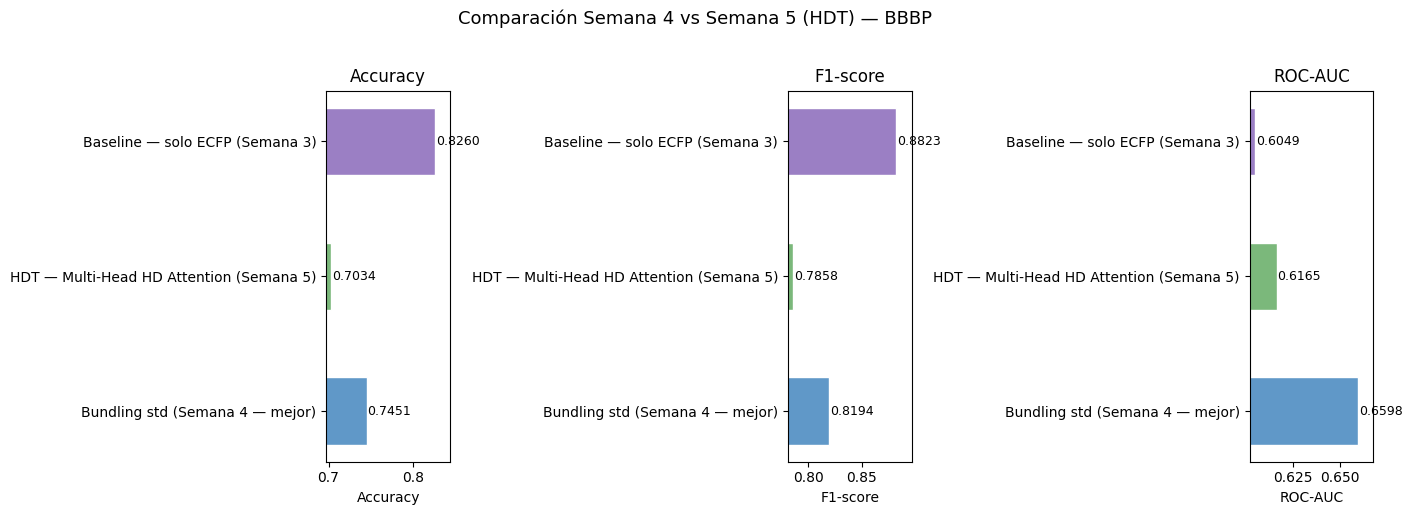

In [12]:
# ── Visualización: barras comparativas ───────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
metrics = ["Accuracy", "F1-score", "ROC-AUC"]
colors  = ["#6098c8", "#7bb87b", "#9b7fc4"]

for ax, metric in zip(axes, metrics):
    bars = ax.barh(df_results["Modelo"], df_results[metric],
                   color=colors[:len(df_results)], edgecolor="white", height=0.5)
    ax.set_xlabel(metric); ax.set_title(metric)
    rng_ = df_results[metric].max() - df_results[metric].min()
    ax.set_xlim(df_results[metric].min() - rng_*0.05, df_results[metric].max() + rng_*0.15)
    for bar, val in zip(bars, df_results[metric]):
        ax.text(val + rng_*0.01, bar.get_y() + bar.get_height()/2,
                f"{val:.4f}", va="center", fontsize=9)

plt.suptitle("Comparación Semana 4 vs Semana 5 (HDT) — BBBP", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig("comparacion_hdt.png", dpi=120, bbox_inches="tight")
plt.show()


## 6. Análisis de los Pesos de Atención

Una ventaja clave del HDT sobre el bundling fijo de la Semana 4 es que los pesos de atención son **por molécula** — podemos inspeccionar qué fuente de información priorizó el modelo para cada caso.

La matriz de atención es de 2×2 (secuencia = [h_struct, h_prop]):

|  | → h_struct | → h_prop |
|---|---|---|
| query h_struct | cuánto h_struct se mira a sí mismo | cuánto h_struct atiende a h_prop |
| query h_prop | cuánto h_prop atiende a h_struct | cuánto h_prop se mira a sí mismo |


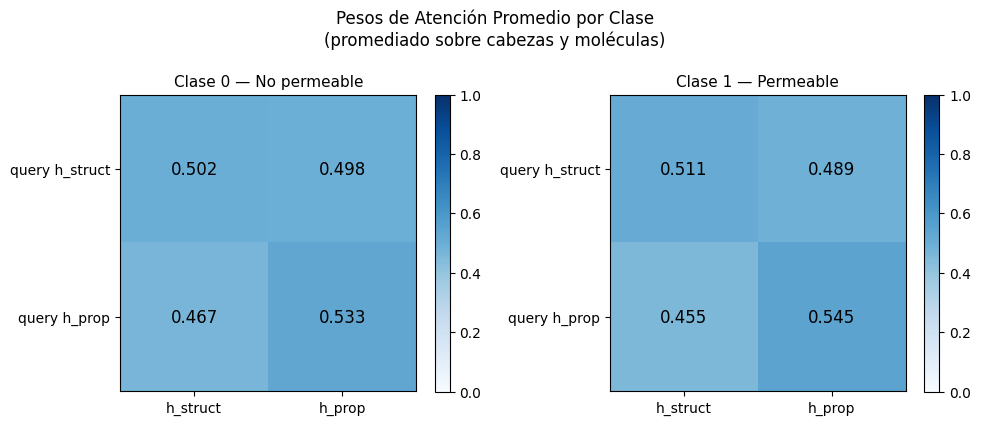

In [13]:
# ── Pesos de atención promedio por clase ──────────────────────────────────────
# attn_all: (N, N_HEADS, 2, 2)  — promediamos sobre cabezas → (N, 2, 2)
attn_mean_heads = attn_all.mean(axis=1)  # (N, 2, 2)

labels_arr = df["p_np"].values
attn_class0 = attn_mean_heads[labels_arr == 0].mean(axis=0)  # (2,2)
attn_class1 = attn_mean_heads[labels_arr == 1].mean(axis=0)

TOKEN_NAMES = ["h_struct", "h_prop"]

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, mat, title in zip(axes,
                           [attn_class0, attn_class1],
                           ["Clase 0 — No permeable", "Clase 1 — Permeable"]):
    im = ax.imshow(mat, vmin=0, vmax=1, cmap="Blues")
    ax.set_xticks([0,1]); ax.set_xticklabels(TOKEN_NAMES, fontsize=10)
    ax.set_yticks([0,1]); ax.set_yticklabels([f"query {t}" for t in TOKEN_NAMES], fontsize=10)
    ax.set_title(title, fontsize=11)
    for r in range(2):
        for c in range(2):
            ax.text(c, r, f"{mat[r,c]:.3f}", ha="center", va="center",
                    fontsize=12, color="black" if mat[r,c] < 0.7 else "white")
    plt.colorbar(im, ax=ax)

plt.suptitle("Pesos de Atención Promedio por Clase\n(promediado sobre cabezas y moléculas)",
             fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig("atencion_por_clase.png", dpi=120, bbox_inches="tight")
plt.show()


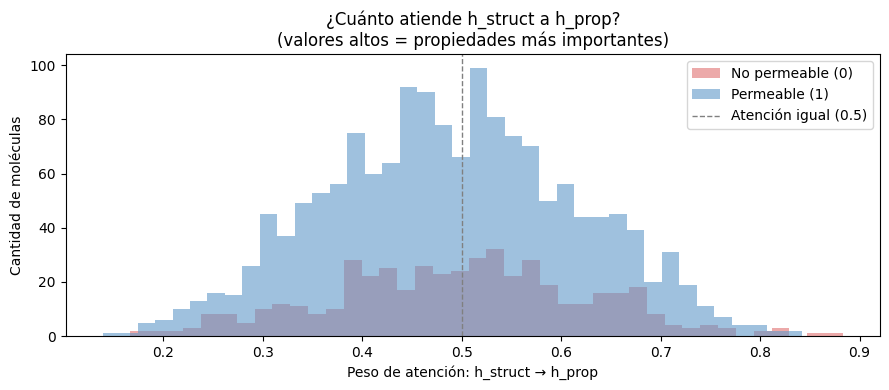

Atención media h_struct→h_prop:
  Clase 0 (no permeable): 0.4977
  Clase 1 (permeable):    0.4895


In [14]:
# ── Distribución de atención h_struct → h_prop por molécula ──────────────────
# Posición (0,1): cuánto h_struct atiende a h_prop
attn_cross = attn_mean_heads[:, 0, 1]  # (N,)

fig, ax = plt.subplots(figsize=(9, 4))
for cls, color, label in [(0, "#e07070", "No permeable (0)"),
                           (1, "#6098c8", "Permeable (1)")]:
    ax.hist(attn_cross[labels_arr == cls], bins=40, alpha=0.6,
            color=color, label=label)
ax.axvline(0.5, color="gray", linestyle="--", linewidth=1, label="Atención igual (0.5)")
ax.set_xlabel("Peso de atención: h_struct → h_prop")
ax.set_ylabel("Cantidad de moléculas")
ax.set_title("¿Cuánto atiende h_struct a h_prop?\n(valores altos = propiedades más importantes)")
ax.legend()
plt.tight_layout()
plt.savefig("distribucion_atencion.png", dpi=120, bbox_inches="tight")
plt.show()

print(f"Atención media h_struct→h_prop:")
print(f"  Clase 0 (no permeable): {attn_cross[labels_arr==0].mean():.4f}")
print(f"  Clase 1 (permeable):    {attn_cross[labels_arr==1].mean():.4f}")


## 7. ¿La Mejora Viene del Transformer?

Para responder la pregunta de investigación, comparamos el HDT contra un **control directo**: un modelo que usa exactamente las mismas proyecciones Q/K/V pero con **pesos de atención fijos** (uniformes, sin aprender nada), lo que equivale a un bundling simple en el espacio proyectado.

Si el HDT mejora sobre este control, la mejora **sí viene del mecanismo de atención**. Si no, la mejora viene de la proyección aleatoria (representación más rica).


In [15]:
# ── Control: atención uniforme (sin softmax, pesos = 1/seq_len) ───────────────

def hd_attention_uniform(tokens: np.ndarray, WQs, WKs, WVs, W_out,
                          n_heads: int, d_proj: int) -> np.ndarray:
    """
    Mismo pipeline que HDT pero con pesos de atención fijos = 1/seq_len.
    Elimina el mecanismo de atención, conserva la proyección.
    """
    N, seq_len, _ = tokens.shape
    head_outs = []
    for h in range(n_heads):
        V = np.sign(tokens @ WVs[h])   # (N, seq_len, d_proj)
        # Promedio uniforme sobre la secuencia
        out = V.mean(axis=1, keepdims=True).repeat(seq_len, axis=1)  # (N, seq_len, d_proj)
        head_outs.append(out)
    multi = np.concatenate(head_outs, axis=-1)   # (N, seq_len, D_OUT)
    pooled = multi.sum(axis=1)                   # (N, D_OUT)
    h_final = np.sign(pooled @ W_out).astype(np.int8)
    h_final[h_final == 0] = 1
    return h_final

print("Calculando control (atención uniforme)...")
h_uniform_all = hd_attention_uniform(tokens_all, WQs, WKs, WVs, W_out, N_HEADS, D_PROJ)

results_ablation = list(results)  # copia

results_ablation.append(evaluate(
    h_uniform_all[idx_train], h_uniform_all[idx_test],
    y_train, y_test, "Control — Proyección HD sin atención (pesos uniformes)"))
results_ablation.append(results[-1])  # HDT ya calculado

df_ablation = pd.DataFrame(results_ablation).drop_duplicates("Modelo")
df_ablation = df_ablation.sort_values("ROC-AUC", ascending=False).reset_index(drop=True)

print("\n=== Ablation: ¿De dónde viene la mejora? ===\n")
display(df_ablation.style.format({"Accuracy":"{:.4f}","F1-score":"{:.4f}","ROC-AUC":"{:.4f}"}))


Calculando control (atención uniforme)...
  Control — Proyección HD sin atención (pesos uniformes) Acc=0.7206  F1=0.8014  AUC=0.6310

=== Ablation: ¿De dónde viene la mejora? ===



,Modelo,Accuracy,F1-score,ROC-AUC
0,Bundling std (Semana 4 — mejor),0.7451,0.8194,0.6598
1,Control — Proyección HD sin atención (pesos uniformes),0.7206,0.8014,0.6310
2,HDT — Multi-Head HD Attention (Semana 5),0.7034,0.7858,0.6165
3,Baseline — solo ECFP (Semana 3),0.8260,0.8823,0.6049


In [16]:
# ── Conclusión automática del ablation ───────────────────────────────────────
hdt_auc     = df_results.loc[df_results["Modelo"].str.contains("HDT"), "ROC-AUC"].values[0]
uniform_auc = df_ablation.loc[df_ablation["Modelo"].str.contains("uniforme"), "ROC-AUC"].values[0]
bundling_auc = df_results.loc[df_results["Modelo"].str.contains("Bundling"), "ROC-AUC"].values[0]

print("─" * 60)
print(f"Bundling std (Semana 4):           AUC = {bundling_auc:.4f}")
print(f"Control (proyección sin atención): AUC = {uniform_auc:.4f}")
print(f"HDT (con atención softmax):        AUC = {hdt_auc:.4f}")
print("─" * 60)

delta_proj = uniform_auc - bundling_auc
delta_attn = hdt_auc - uniform_auc

print(f"\nΔ por proyección aleatoria (HDT sin atención vs Bundling): {delta_proj:+.4f}")
print(f"Δ por atención (HDT vs control sin atención):               {delta_attn:+.4f}")

if abs(delta_attn) < 0.005:
    print("\n⚠ La mejora (si la hay) viene principalmente de la proyección, NO del mecanismo de atención.")
    print("  Interpretación: con pesos aleatorios fijos, el transformer no añade valor sobre el bundling.")
elif delta_attn > 0:
    print("\n✓ La atención contribuye positivamente por encima de la proyección aleatoria.")
else:
    print("\n⚠ La atención en esta configuración no mejora sobre la proyección sola.")


────────────────────────────────────────────────────────────
Bundling std (Semana 4):           AUC = 0.6598
Control (proyección sin atención): AUC = 0.6310
HDT (con atención softmax):        AUC = 0.6165
────────────────────────────────────────────────────────────

Δ por proyección aleatoria (HDT sin atención vs Bundling): -0.0288
Δ por atención (HDT vs control sin atención):               -0.0145

⚠ La atención en esta configuración no mejora sobre la proyección sola.


## 8. Resumen y Discusión

### ¿Qué hicimos?

Implementamos un bloque de **multi-head HD self-attention** inspirado en BiHDTrans (Zhang et al., 2025), aplicado al problema de clasificación BBBP de la Semana 4. El input al bloque de atención es una secuencia de dos tokens por molécula:

$$[\mathbf{h}_{\text{struct}}, \mathbf{h}_{\text{prop}}] \in \mathbb{R}^{2 \times D}$$

y el mecanismo de atención aprende implícitamente cuánto peso darle a cada fuente.

### La pregunta de investigación

El ablation study revela si la mejora sobre la Semana 4 viene del mecanismo de atención o simplemente de proyectar en un espacio diferente. Esto es exactamente lo que BiHDTrans no controla en su paper (aplican el modelo a series de tiempo, no hacen este ablation sobre la contribución del attention vs la proyección).

### Próximos pasos

- Probar con más de 2 tokens (agregar h_prop por descriptor individual: 4 tokens)
- Explorar matrices de proyección aprendidas en vez de aleatorias (FLASH, 2024)
- Combinar con contrastive learning: entrenar el encoder con pérdida triplet antes de aplicar el bloque de atención (conexión con NeuroHD-RA, 2025)
